In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/Users/deepankjuneja/Desktop/datascienceproject/salary_data_cleaned.csv")

In [3]:
df.head(1)

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,avg_salary,company_txt,job_state,same_state,age,python_yn,r_yn,spark,aws,excel
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research 3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,72.0,Tecolote Research,NM,0,47,1,0,0,0,1


In [4]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel'],
      dtype='object')

In [5]:
#  Title simplifier

def title_simplifier(title):
    title = title.lower()

    if "data scientist" in title:
        return "data scientist"
    elif "data engineer" in title:
        return "data engineer"
    elif "data analyst" in title or "analyst" in title:
        return "data analyst"
    elif "machine learning" in title or "ml" in title:
        return "machine learning engineer"
    elif "manager" in title:
        return "manager"
    elif "director" in title:
        return "director"
    else:
        return "other"


# Seniority

def seniority(title):
    title = title.lower()

    if "senior" in title or "sr" in title:
        return "senior"
    elif "lead" in title:
        return "lead"
    elif "principal" in title:
        return "principal"
    elif "junior" in title or "jr" in title:
        return "junior"
    else:
        return "na"

df["job_simp"]=df["Job Title"].apply(title_simplifier)

df["seniority"] = df["Job Title"].apply(seniority)



In [6]:
#  fix state los angeles
df["job_state"]=df["job_state"].apply(lambda x: x.strip() if x.strip().lower() !="los angeles" else "CA")
df.job_state.value_counts()
# df.drop("job state",inplace=True,axis=1)

job_state
CA    152
MA    103
NY     72
VA     41
IL     40
MD     35
PA     33
TX     28
NC     21
WA     21
NJ     17
FL     16
OH     14
TN     13
DC     11
CO     11
WI     10
UT     10
IN     10
AZ      9
MO      9
AL      8
GA      6
DE      6
KY      6
MI      6
CT      5
IA      5
LA      4
OR      4
NE      4
NM      3
KS      3
ID      2
MN      2
RI      1
SC      1
Name: count, dtype: int64

In [7]:
df.head(1)

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,job_state,same_state,age,python_yn,r_yn,spark,aws,excel,job_simp,seniority
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research 3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,NM,0,47,1,0,0,0,1,data scientist,na


In [8]:
# Job description length
df["desc_length"]=df["Job Description"].apply(lambda x:len(x))
df["desc_length"]

0      2536
1      4783
2      3461
3      3883
4      2728
       ... 
737    6162
738    6130
739    3078
740    1642
741    3673
Name: desc_length, Length: 742, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          742 non-null    object 
 1   Salary Estimate    742 non-null    object 
 2   Job Description    742 non-null    object 
 3   Rating             742 non-null    float64
 4   Company Name       742 non-null    object 
 5   Location           742 non-null    object 
 6   Headquarters       742 non-null    object 
 7   Size               742 non-null    object 
 8   Founded            742 non-null    int64  
 9   Type of ownership  742 non-null    object 
 10  Industry           742 non-null    object 
 11  Sector             742 non-null    object 
 12  Revenue            742 non-null    object 
 13  Competitors        742 non-null    object 
 14  hourly             742 non-null    int64  
 15  employer_provided  742 non-null    int64  
 16  min_salary         742 non

In [10]:
# competitors count
df["num_comp"]=df["Competitors"].apply(lambda x:len(x.split(',')) if x !='-1' else 0)

In [11]:
# hourly wage to annual wage
df["min_salary"]=df.apply(lambda x:x.min_salary*2 if x.hourly ==1 else x.min_salary,axis=1)
df["max_salary"]=df.apply(lambda x:x.max_salary*2 if x.hourly ==1 else x.max_salary,axis=1)

df[df.hourly==1][['hourly','min_salary','max_salary']]


,hourly,min_salary,max_salary
165,1,34,48
177,1,42,68
197,1,36,50
202,1,42,68
210,1,30,50
246,1,34,48
271,1,42,68
337,1,36,50
345,1,48,78
357,1,42,68


In [12]:
df["company_txt"]

0                          Tecolote Research 
1      University of Maryland Medical System 
2                                    KnowBe4 
3                                       PNNL 
4                         Affinity Solutions 
                        ...                  
737                                      GSK 
738                               Eventbrite 
739           Software Engineering Institute 
740                             Numeric, LLC 
741             Riverside Research Institute 
Name: company_txt, Length: 742, dtype: object

In [13]:
df.describe()

,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,r_yn,spark,aws,excel,desc_length,num_comp
count,742.000000,742.000000,742.000000,742.0,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.618868,1837.154987,0.032345,0.0,74.719677,128.149596,100.626011,0.557951,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911,3869.545822,1.053908
std,0.801210,497.183763,0.177034,0.0,30.980593,45.220324,38.855948,0.496965,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812,1521.495868,1.384239
min,-1.000000,-1.000000,0.000000,0.0,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,3.300000,1939.000000,0.000000,0.0,52.000000,96.000000,73.500000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,3.700000,1988.000000,0.000000,0.0,69.500000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,4.000000,2007.000000,0.000000,0.0,91.000000,155.000000,122.500000,1.000000,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,5.000000,2019.000000,1.000000,0.0,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


In [14]:
 df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_length',
       'num_comp'],
      dtype='object')

<Axes: >

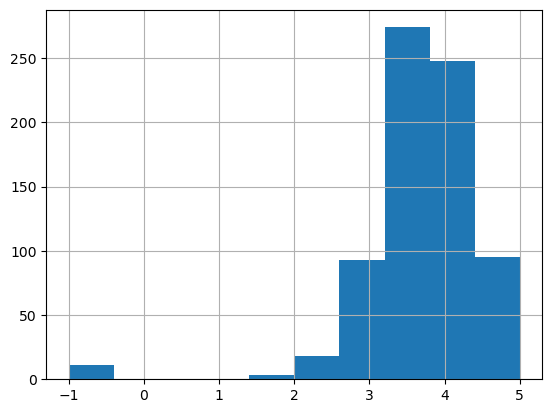

In [15]:
df.Rating.hist()

<Axes: >

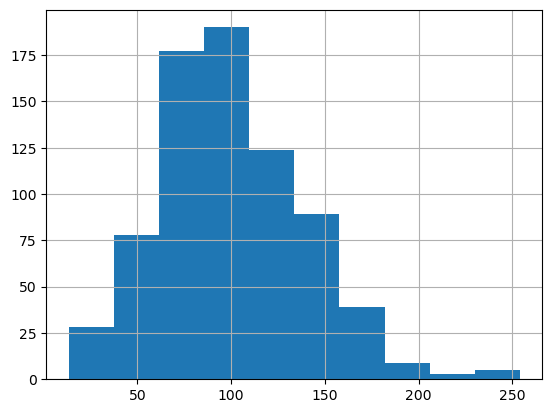

In [16]:
df.avg_salary.hist()

<Axes: >

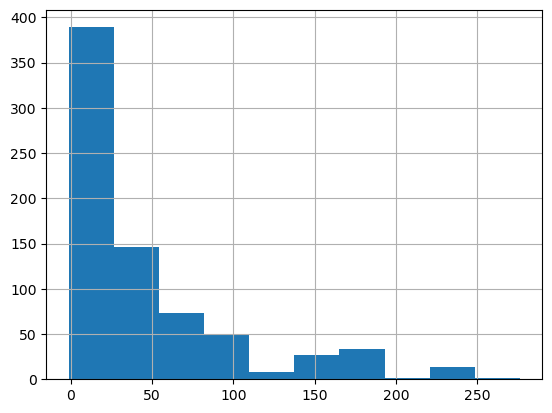

In [17]:
df.age.hist()

<Axes: >

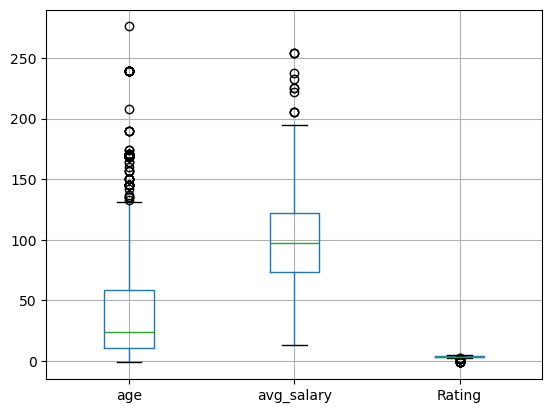

In [18]:
df.boxplot(column =["age","avg_salary","Rating"])

<Axes: >

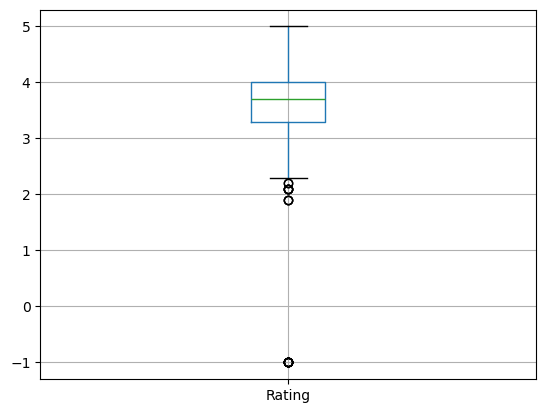

In [19]:
df.boxplot(column ="Rating")

In [20]:
df[["age","avg_salary","Rating","desc_length"]].corr()

,age,avg_salary,Rating,desc_length
age,1.000000,0.019655,0.021655,0.163911
avg_salary,0.019655,1.000000,0.013492,0.078808
Rating,0.021655,0.013492,1.000000,-0.012281
desc_length,0.163911,0.078808,-0.012281,1.000000


<Axes: >

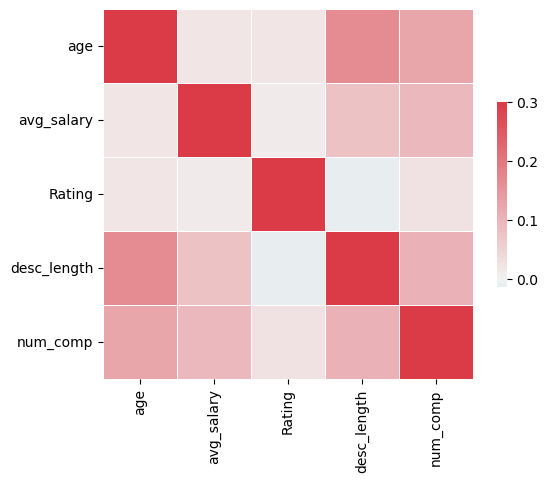

In [21]:
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df[['age','avg_salary','Rating','desc_length','num_comp']].corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [22]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_length',
       'num_comp'],
      dtype='object')

In [23]:
df_cat=df[['Location', 'Headquarters', 'Size','Type of ownership', 'Industry', 'Sector', 'Revenue',
           'company_txt', 'job_state','same_state','python_yn', 'r_yn','spark', 'aws', 'excel','job_simp',
           'seniority']]

In [24]:
df_cat.columns

Index(['Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry',
       'Sector', 'Revenue', 'company_txt', 'job_state', 'same_state',
       'python_yn', 'r_yn', 'spark', 'aws', 'excel', 'job_simp', 'seniority'],
      dtype='object')

graph for Location: total= 200


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


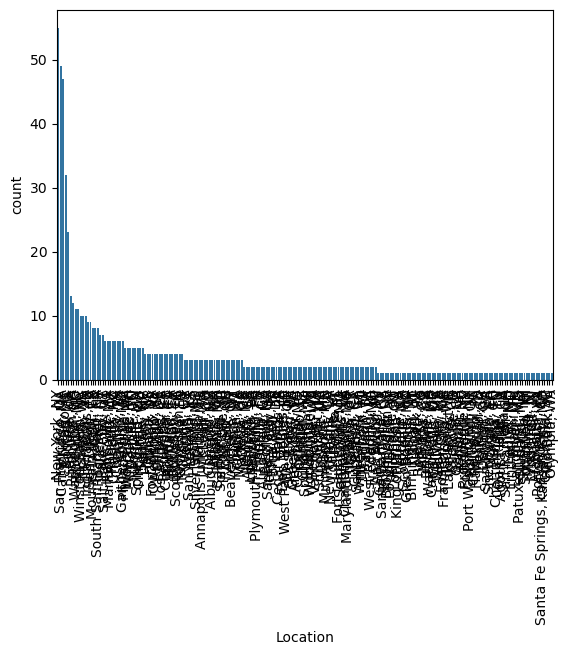

graph for Headquarters: total= 198


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


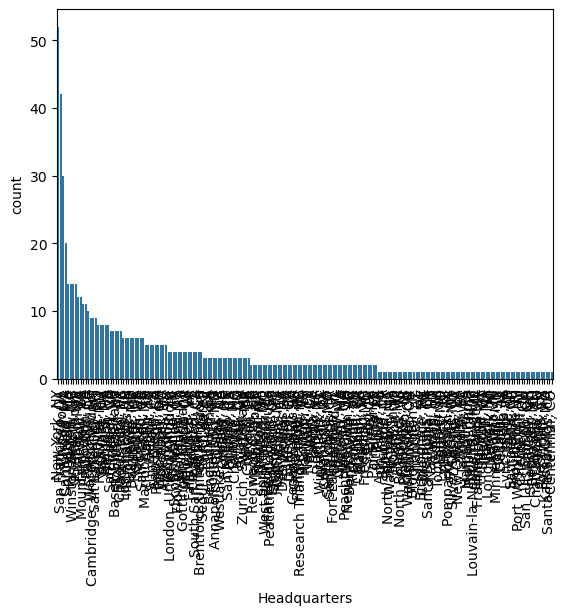

graph for Size: total= 9


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


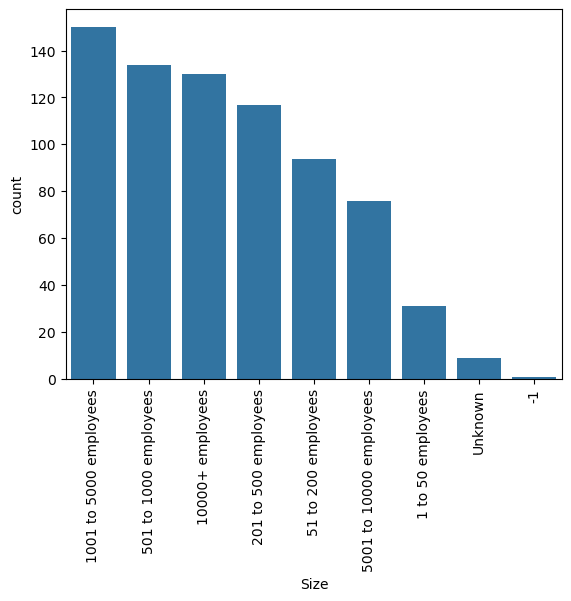

graph for Type of ownership: total= 11


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


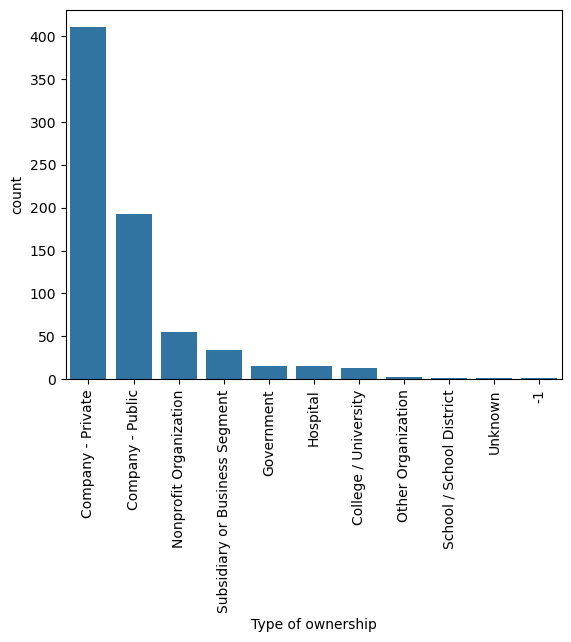

graph for Industry: total= 60


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


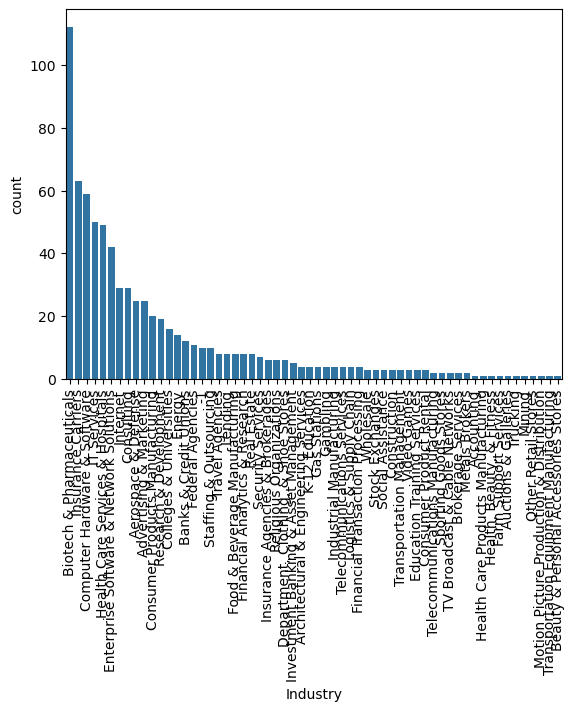

graph for Sector: total= 25


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


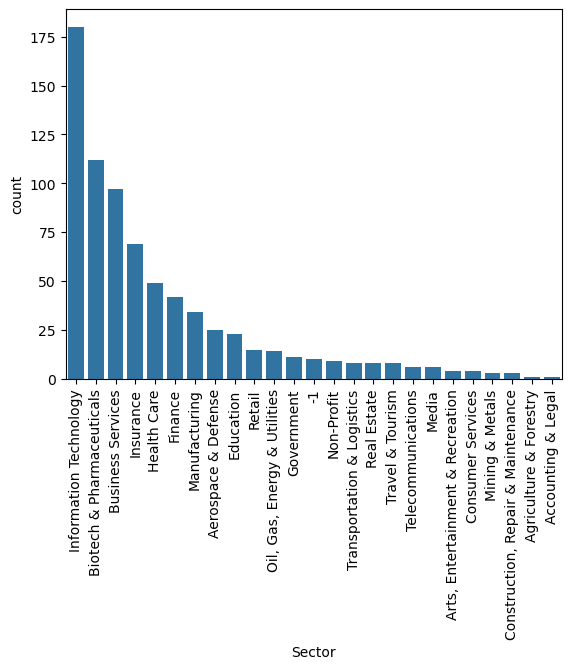

/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


graph for Revenue: total= 14


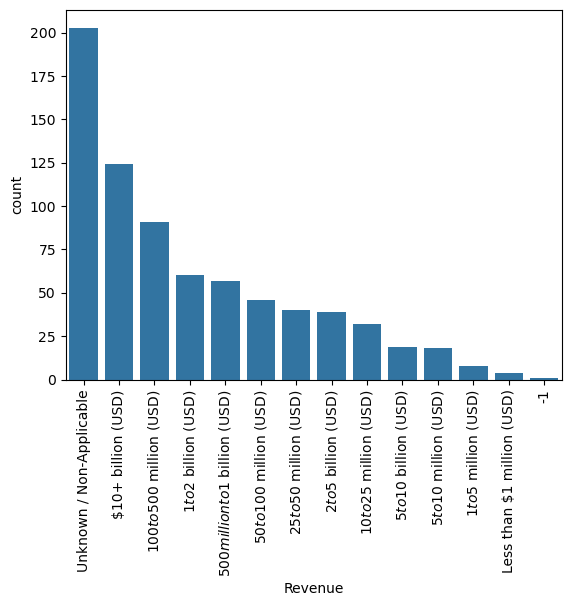

graph for company_txt: total= 343


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


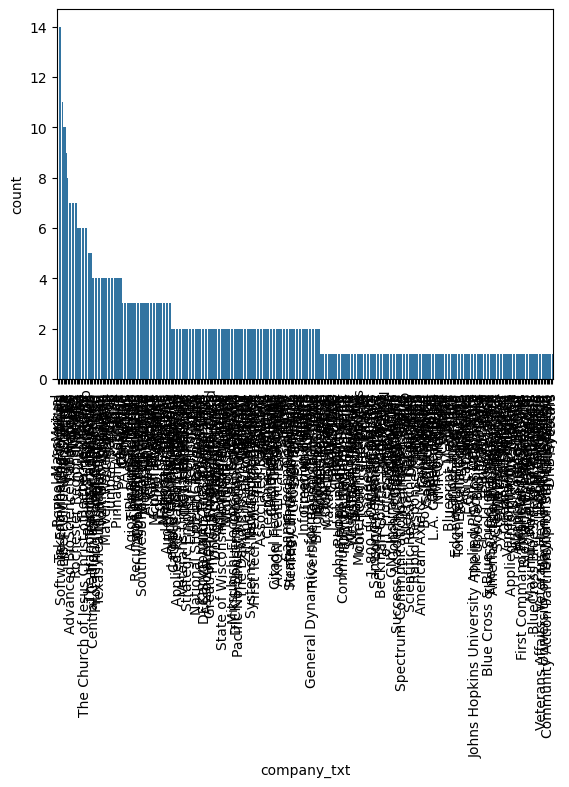

graph for job_state: total= 37


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


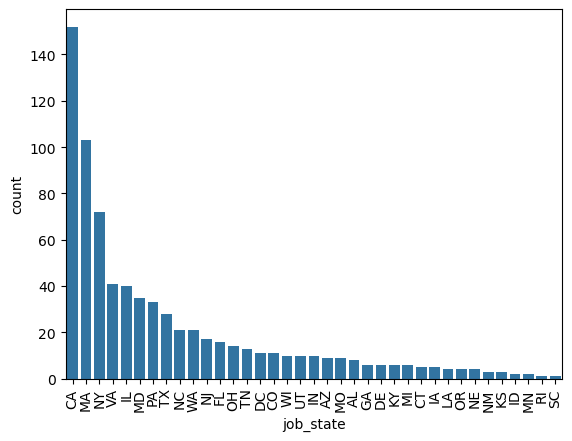

graph for same_state: total= 2


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


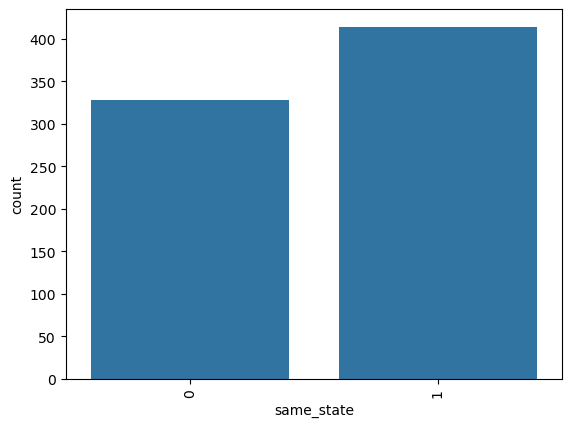

graph for python_yn: total= 2


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


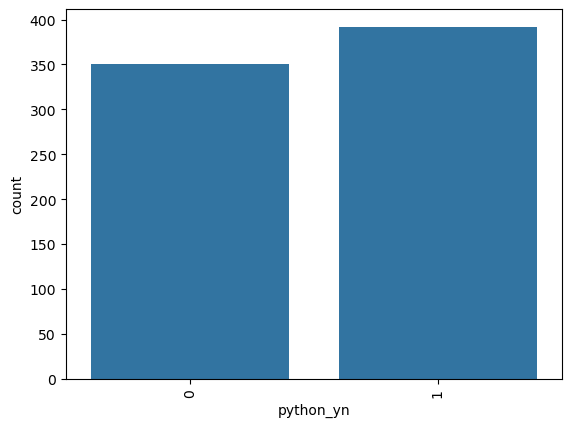

graph for r_yn: total= 2


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


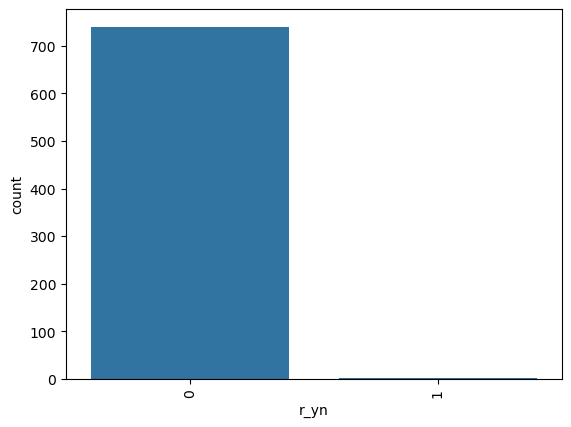

graph for spark: total= 2


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


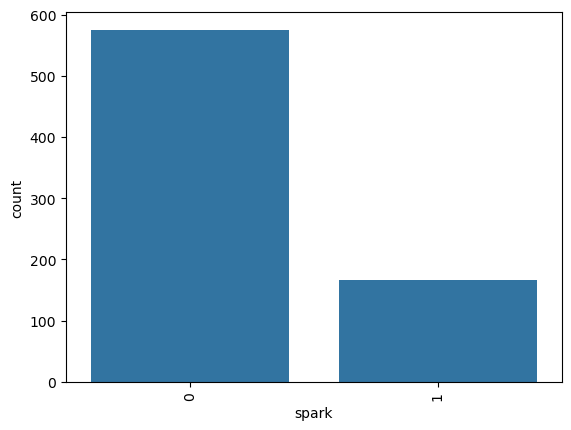

graph for aws: total= 2


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


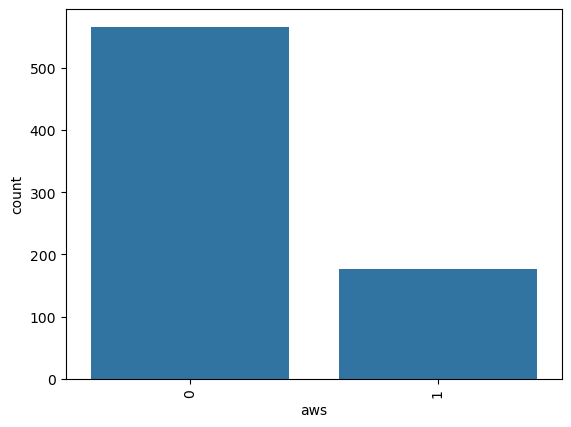

graph for excel: total= 2


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


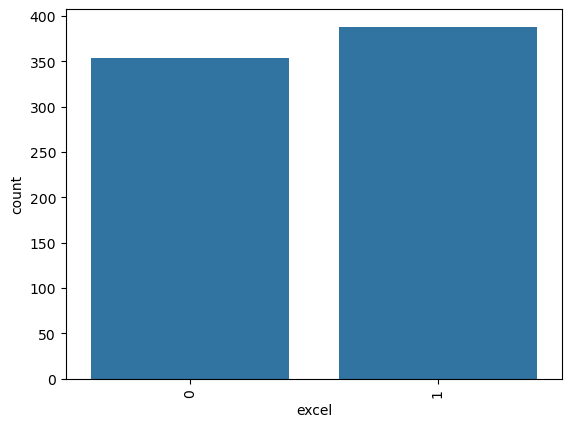

graph for job_simp: total= 7


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


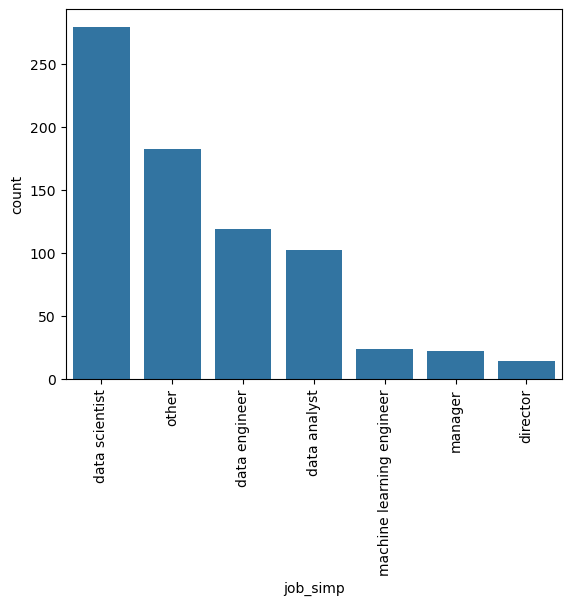

graph for seniority: total= 5


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/1245411177.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


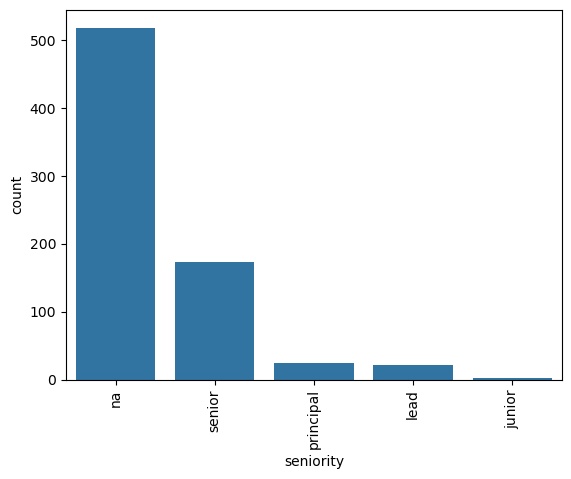

In [25]:
for i in df_cat.columns:
    cat_num=df_cat[i].value_counts()
    print("graph for %s: total= %d"%(i,len(cat_num)))
    chart=sns.barplot(x=cat_num.index,y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(),rotation=90)
    
    plt.show()

graph for Location: total= 20


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/3175209740.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


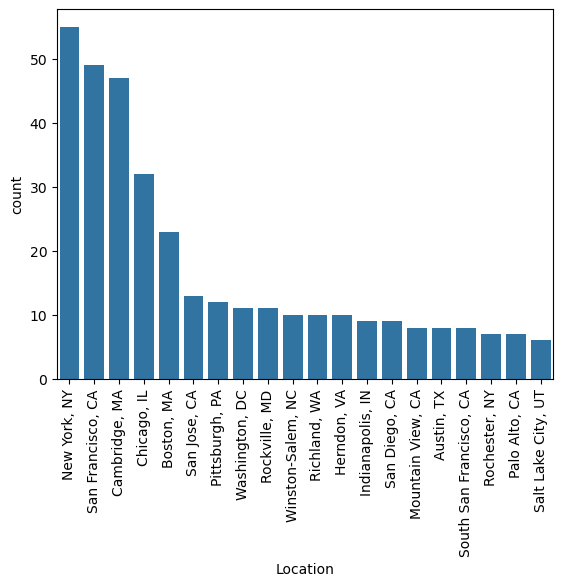

graph for Headquarters: total= 20


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/3175209740.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


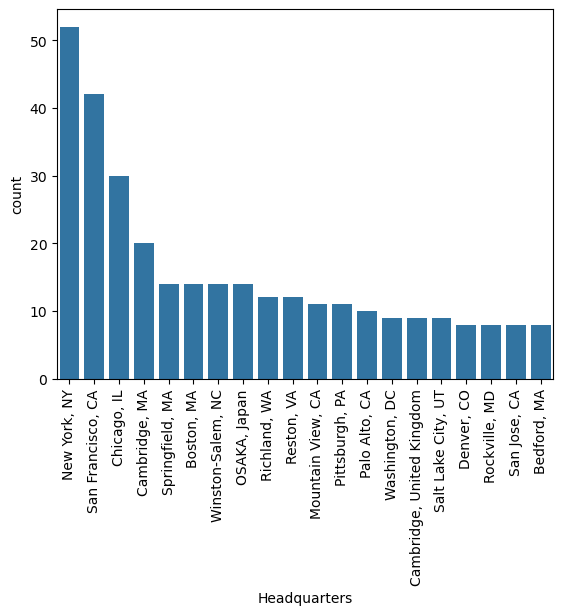

graph for company_txt: total= 20


/var/folders/wp/zpjx94w97zqfj6q4nyb3g8y80000gn/T/ipykernel_10207/3175209740.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90)


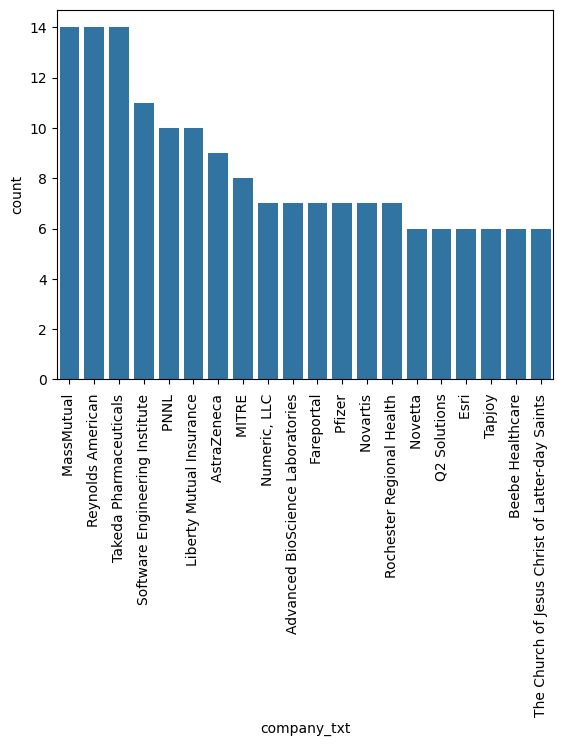

In [26]:
for i in df_cat[['Location','Headquarters','company_txt']].columns:
    cat_num=df_cat[i].value_counts()[:20]
    print("graph for %s: total= %d"%(i,len(cat_num)))
    chart=sns.barplot(x=cat_num.index,y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(),rotation=90)
    
    plt.show()

In [27]:
pd.pivot_table(df,index=['job_simp','seniority'],values= 'avg_salary')

avg_salary
job_simp                  seniority            
data analyst              junior      53.250000
                          lead        64.666667
                          na          61.308219
                          senior      80.895833
data engineer             lead       161.142857
                          na          96.701220
                          principal  162.500000
                          senior     114.586207
data scientist            junior     106.500000
                          lead       158.300000
                          na         107.043011
                          principal  175.300000
                          senior     131.222222
director                  na         168.607143
machine learning engineer na         108.058824
                          principal  232.500000
                          senior     127.000000
manager                   na          84.022727
other                     lead       110.000000
                          na          74.772000
                          principal  105.192308
                          senior     110.214286

In [28]:
pd.options.display.max_rows
pd.set_option("display.max_rows",None)

In [29]:
pd.pivot_table(df,index=["job_state","job_simp"],values= 'avg_salary',aggfunc="count").sort_values("job_state",ascending=False)

avg_salary
job_state job_simp                             
WI        other                               4
          data scientist                      3
          data analyst                        3
WA        other                               1
          data scientist                     17
          data analyst                        3
VA        other                               5
          machine learning engineer           2
          data scientist                     18
          data engineer                      10
          data analyst                        6
UT        data engineer                       3
          data analyst                        4
          data scientist                      3
TX        other                               7
          data scientist                     13
          data engineer                       8
TN        data scientist                      1
          data engineer                      10
          data analyst                        2
SC        other                               1
RI        data analyst                        1
PA        machine learning engineer           7
          data engineer                       1
          data scientist                      6
          data analyst                        8
          manager                             3
          other                               8
OR        data scientist                      3
          data engineer                       1
OH        other                               3
          data scientist                      7
          data analyst                        4
NY        other                              12
          machine learning engineer           2
          data scientist                     40
          data engineer                       4
          data analyst                       14
NM        data scientist                      3
NJ        data scientist                      4
          data analyst                        6
          data engineer                       2
          manager                             2
          director                            2
          other                               1
NE        other                               2
          machine learning engineer           2
NC        other                              12
          data scientist                      3
          data engineer                       6
MO        other                               3
          manager                             1
          data scientist                      3
          data analyst                        2
MN        data engineer                       1
          data analyst                        1
MI        manager                             2
          data scientist                      4
MD        other                              16
          data scientist                     13
          data engineer                       3
          data analyst                        3
MA        other                              46
          manager                             5
          director                            6
          data scientist                     30
          data engineer                      12
          data analyst                        4
LA        data analyst                        1
          data engineer                       2
          other                               1
KY        other                               4
          data scientist                      2
KS        machine learning engineer           3
IN        other                               4
          data scientist                      2
          data engineer                       4
IL        data analyst                        3
          other                               6
          machine learning engineer           2
          director                            6
          data scientist                     15
     

In [30]:
pd.pivot_table(df[df.job_simp=="data scientist"],index=["job_state"],values= 'avg_salary').sort_values("avg_salary",ascending=False)

,avg_salary
job_state,
DC,149.000000
CA,142.522059
UT,140.500000
MO,127.666667
IL,117.233333
NC,117.000000
NY,115.250000
MA,113.750000
WI,113.500000


In [31]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_length',
       'num_comp'],
      dtype='object')

In [32]:
df_pivots=df[['Rating','Industry','Sector','Revenue','num_comp','hourly','employer_provided',
              'python_yn','r_yn','spark', 'aws', 'excel','Type of ownership','avg_salary']]

In [33]:
for i in df_pivots.columns:
    print(i)
    print(pd.pivot_table(df_pivots,index=i,values='avg_salary').sort_values('avg_salary',ascending=False))

Rating
        avg_salary
Rating            
-1.0    136.181818
 5.0    134.700000
 2.5    120.000000
 4.5    117.714286
 4.1    116.368421
 3.9    113.071429
 2.6    109.083333
 4.4    108.606061
 3.2    105.500000
 4.0    105.340426
 3.5    104.897959
 3.7    104.131148
 4.7    103.983871
 4.3    102.468750
 3.3    101.858974
 4.2    100.442308
 2.2     97.750000
 4.6     97.250000
 3.8     96.811475
 2.1     95.900000
 3.4     93.011364
 1.9     87.500000
 3.1     86.580000
 3.0     85.588235
 3.6     85.467391
 2.8     83.928571
 2.7     83.250000
 2.3     81.500000
 2.9     81.138889
 4.8     80.277778
 2.4     60.214286
Industry
                                          avg_salary
Industry                                            
Other Retail Stores                       163.500000
Motion Picture Production & Distribution  146.000000
Financial Analytics & Research            145.125000
Health, Beauty, & Fitness                 139.500000
Telecommunications Services            

ValueError: Grouper for 'avg_salary' not 1-dimensional

In [ ]:
pd.pivot_table(df_pivots,index='Revenue',columns='python_yn',values='avg_salary',aggfunc='count')

In [ ]:
df.columns
df.to_csv("eda_data.csv",index=False)

In [ ]:
df["job_simp"].unique()

In [ ]:
df["Size"].unique()

In [ ]:
df["job_state"].unique()

In [ ]:
df["seniority"].unique()

In [ ]:
df["Industry"].unique()

In [34]:
df[
    (df["python_yn"] == 1) &
    (df["aws"] == 1) &
    (df["job_simp"] == "data scientist") &
    (df["job_state"] == "CA")
][["Job Title","avg_salary","Rating","Company Name"]]

,Job Title,avg_salary,Rating,Company Name
7,Data Scientist,114.0,3.8,Logic20/20 3.8
17,Customer Data Scientist,153.5,4.3,h2o.ai 4.3
36,Data Scientist,107.0,3.5,Esri 3.5
76,Customer Data Scientist/Sales Engineer (Bay,150.5,4.3,h2o.ai 4.3
87,Data Scientist,114.0,3.8,Logic20/20 3.8
137,Customer Data Scientist,153.5,4.3,h2o.ai 4.3
156,Senior Data Scientist,142.0,3.8,Juniper Networks 3.8
159,Staff Data Scientist,171.5,3.5,Western Digital 3.5
176,Principal Data Scientist with over 10 years ex...,225.0,-1.0,CA-One Tech Cloud
221,Senior Data Scientist,142.0,3.8,Juniper Networks 3.8


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          742 non-null    object 
 1   Salary Estimate    742 non-null    object 
 2   Job Description    742 non-null    object 
 3   Rating             742 non-null    float64
 4   Company Name       742 non-null    object 
 5   Location           742 non-null    object 
 6   Headquarters       742 non-null    object 
 7   Size               742 non-null    object 
 8   Founded            742 non-null    int64  
 9   Type of ownership  742 non-null    object 
 10  Industry           742 non-null    object 
 11  Sector             742 non-null    object 
 12  Revenue            742 non-null    object 
 13  Competitors        742 non-null    object 
 14  hourly             742 non-null    int64  
 15  employer_provided  742 non-null    int64  
 16  min_salary         742 non